# S1 · Explore and Extract 3D WRF Subsets

This notebook guides you through two tasks:

1. **Choose a geographic region of interest** from the WRF domain and find
   the corresponding grid indices.
2. **Extract and save a 3D ensemble subset** as a compressed `.npz` file
   ready for data assimilation experiments.

The extraction logic lives in `src/extract_3d_subset.py` so the same
function can be called from the command line without opening this notebook.

Two input formats are supported — set `FORMAT` in Step 1:

| Format | Files | Library |
|--------|-------|---------|
| `wrfout` | Native WRF output (`wrfout_d01_*`) | wrf-python |
| `post` | Postprocessed CF-convention netCDF | netCDF4 only |

Both formats produce identical `.npz` output.

---
## Step 1 · Configuration

Set the format, sample file path, and bounding box here.
Everything else in the notebook reads from these variables.


In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "../src"))
sys.path.insert(0, os.path.join(os.getcwd(), "../src/fortran"))
# Choose format
FORMAT = "post"      # "wrfout"  or  "post"

# Path to ONE sample file (used only for grid metadata)
if FORMAT == "wrfout":
    SAMPLE_FILE = (
        "/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/"
        "PREVENIR_LOWRESOLUTION_HYDRA_2023121612/HIST/FCST/"
        "20231216120000/001/wrfout_d01_2023-12-16_19:00:00"
    )
else:
    SAMPLE_FILE = (
        "/home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT/POST/GUES/20240319180000/WRF.D20240319180000.T2D.M001.nc"
    )
# ──────────────────────────────────────────────────────────────────────────
print(f"Format : {FORMAT}")
print(f"Sample : {SAMPLE_FILE}")

Format : post
Sample : /home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT/POST/GUES/20240319180000/WRF.D20240319180000.T2D.M001.nc


In [2]:
import sys, os
import wrf
import numpy as np
from netCDF4 import Dataset
from cletkf_wloc import common_da as cda
import warnings
warnings.filterwarnings("ignore")


def get_refl_and_coords(nc):
    """Extracts column-max reflectivity and coordinates independent of format."""

    lats = nc.variables["XLAT"][:]
    lons = nc.variables["XLONG"][:]
    qr = nc.variables["QRAIN"][0, :, :, :]  # (nz, ny, nx)
    qs = nc.variables["QSNOW"][0, :, :, :]  # (nz, ny, nx)
    qg = nc.variables["QGRAUP"][0, :, :, :]  # (nz, ny, nx)
    tk = nc.variables["T"][0, :, :, :]  # temperature [K]
    p  = nc.variables["PRESSURE"][0, :, :, :]  # pressure [Pa]

    nz, ny, nx = qr.shape
    dbz_3d = np.zeros((nz, ny, nx), dtype=np.float32)
    for k in range(nz):
        for j in range(ny):
            for i in range(nx):
                dbz_3d[k, j, i] = cda.calc_ref(
                    qr[k, j, i], qs[k, j, i], qg[k, j, i],
                    tk[k, j, i], p[k, j, i]
                    )
    return dbz_3d, lats, lons 

# Load the array into memory
nc = Dataset(SAMPLE_FILE)
refl, lats, lons = get_refl_and_coords(nc)
print(f"Successfully loaded Reflectivity array of shape {refl.shape} from {FORMAT} file.")

KeyError: 'QRAIN'

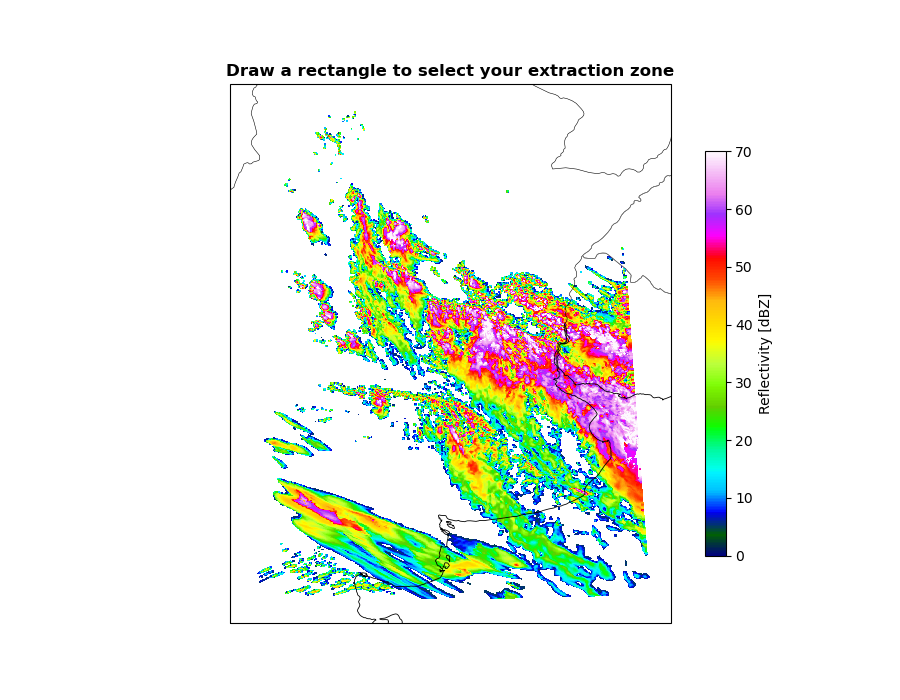

In [10]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the format-agnostic reflectivity field
data_plot = np.ma.masked_less(refl.max(axis=0), 5)
mesh = ax.pcolormesh(lons, lats, data_plot, cmap="gist_ncar", vmin=0, vmax=70, shading='auto')
ax.coastlines(resolution="10m", linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='gray')
plt.colorbar(mesh, ax=ax, label="Reflectivity [dBZ]", shrink=0.75)
ax.set_title("Draw a rectangle to select your extraction zone", fontweight="bold")

# Dictionary to hold coordinates dynamically
selected_bbox = {}

def toggle_selector(eclick, erelease):
    """Callback triggered when the RectangleSelector is drawn/adjusted."""
    lon_min, lon_max = min(eclick.xdata, erelease.xdata), max(eclick.xdata, erelease.xdata)
    lat_min, lat_max = min(eclick.ydata, erelease.ydata), max(eclick.ydata, erelease.ydata)
    
    selected_bbox['LAT_LL'] = lat_min
    selected_bbox['LON_LL'] = lon_min
    selected_bbox['LAT_UR'] = lat_max
    selected_bbox['LON_UR'] = lon_max
    print(f"Selected Region -> Lat: [{lat_min:.2f}, {lat_max:.2f}] | Lon: [{lon_min:.2f}, {lon_max:.2f}]")

# Initialize the interactive selector
rs = RectangleSelector(ax, toggle_selector,
                       useblit=True,
                       button=[1], # Active on Left Mouse Button
                       minspanx=1, minspany=1,
                       spancoords='data',
                       interactive=True)
plt.show()

---
## Step 2 · Find grid indices for the region of interest

Finds the nearest grid point to each bounding box corner and prints the
indices ready to paste into your YAML config.


In [4]:
#if not selected_bbox:
#    raise ValueError("Please draw a bounding box on the map in Step 2 first!")

# Read dynamically from the selector
LAT_LL = -41.5#selected_bbox['LAT_LL']
LON_LL = -68.6#selected_bbox['LON_LL']
LAT_UR = -25.3#selected_bbox['LAT_UR']
LON_UR = -55.4#selected_bbox['LON_UR']

In [5]:
import numpy as np
from netCDF4 import Dataset
#silence warnings deprecated
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

if FORMAT == "wrfout":
    import wrf
    with Dataset(SAMPLE_FILE) as nc:
        xy_ll = wrf.ll_to_xy(nc, LAT_LL, LON_LL)
        xy_ur = wrf.ll_to_xy(nc, LAT_UR, LON_UR)
        lat_ll_wrf, lon_ll_wrf = wrf.xy_to_ll(nc, xy_ll[0], xy_ll[1])
        lat_ur_wrf, lon_ur_wrf = wrf.xy_to_ll(nc, xy_ur[0], xy_ur[1])
    i_start = int(xy_ll.values[0]);  i_end = int(xy_ur.values[0]) + 1
    j_start = int(xy_ll.values[1]);  j_end = int(xy_ur.values[1]) + 1
    lat_ll_wrf = float(lat_ll_wrf);  lon_ll_wrf = float(lon_ll_wrf)
    lat_ur_wrf = float(lat_ur_wrf);  lon_ur_wrf = float(lon_ur_wrf)

else:
    from extract_3d_subset import ll_to_ij_post
    j_start, i_start = ll_to_ij_post(SAMPLE_FILE, LAT_LL, LON_LL)
    j_end,   i_end   = ll_to_ij_post(SAMPLE_FILE, LAT_UR, LON_UR)
    i_end += 1;  j_end += 1   # +1 for Python slicing
    with Dataset(SAMPLE_FILE) as nc:
        xlat  = nc.variables["XLAT"][:]
        xlong = nc.variables["XLONG"][:]
    lat_ll_wrf = float(xlat [j_start, i_start])
    lon_ll_wrf = float(xlong[j_start, i_start])
    lat_ur_wrf = float(xlat [j_end-1, i_end-1])
    lon_ur_wrf = float(xlong[j_end-1, i_end-1])

print("Requested bounding box:")
print(f"  lat: [{LAT_LL}, {LAT_UR}]   lon: [{LON_LL}, {LON_UR}]")
print()
print("Snapped WRF grid corners:")
print(f"  lat_ll={lat_ll_wrf:.4f}  lon_ll={lon_ll_wrf:.4f}")
print(f"  lat_ur={lat_ur_wrf:.4f}  lon_ur={lon_ur_wrf:.4f}")
print()
print("Paste into your YAML config (subset_3d block):")
print(f"  i_start: {i_start}")
print(f"  i_end:   {i_end}")
print(f"  j_start: {j_start}")
print(f"  j_end:   {j_end}")

Requested bounding box:
  lat: [-41.5, -25.3]   lon: [-68.6, -55.4]

Snapped WRF grid corners:
  lat_ll=-41.4812  lon_ll=-68.6130
  lat_ur=-25.3135  lon_ur=-55.4147

Paste into your YAML config (subset_3d block):
  i_start: 140
  i_end:   447
  j_start: 222
  j_end:   673


---
## Step 3 · Visualise the region on the full domain

The map below shows the full ensemble rainfall field and highlights the
selected bounding box.  Adjust `highlight_idx` to inspect individual
members or set it to `-1` to show the ensemble mean.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings("ignore")

_proj     = ccrs.PlateCarree()
_states   = cfeature.NaturalEarthFeature("cultural",
              "admin_1_states_provinces_lines","10m",facecolor="none",edgecolor="gray")
_countries= cfeature.NaturalEarthFeature("cultural",
              "admin_0_countries","10m",facecolor="none",edgecolor="black")

def _map_features(ax):
    #ax.set_extent([-68,-55,-45,-35], crs=_proj)
    ax.coastlines(resolution="10m", linewidth=0.6)
    ax.add_feature(_countries, linewidth=0.4)
    ax.add_feature(_states,    linewidth=0.4)
    #ax.set_xticks([]); ax.set_yticks([])

def _bbox(lat_ll, lon_ll, lat_ur, lon_ur, lw=2):
    return patches.Rectangle(
        (lon_ll, lat_ll), lon_ur-lon_ll, lat_ur-lat_ll,
        facecolor="none", edgecolor="black",
        linewidth=lw, transform=_proj, zorder=5)


In [ ]:
####### Cofiguration for plotting #######
highlight_idx = -1   # -1 = ensemble mean, 0-29 = individual member
vlim_min, vlim_max = 1, 40  # colorbar limits (mm of rain)

nens = 30                 # total number of ensemble members
x_layout, y_layout = 6, 6  # grid layout for plotting (total panels = x_layout * y_layout)
x_main, y_main = 4, 4      # size of main panel (in top-left corner), rest are surrounding members
n_surrounding = x_layout * y_layout - x_main * y_main  # total panels minus main panel
ensemble_rain = []

##### Extract 1 h accumulated rain for all members ######
for m_idx in range(nens):
    mem = f"{m_idx+1:03}"
    f1 = os.path.join(base_path, mem, "wrfout_d01_2023-12-16_18:00:00")
    f2 = os.path.join(base_path, mem, "wrfout_d01_2023-12-16_19:00:00")
    with Dataset(f1) as nc1, Dataset(f2) as nc2:
        lat = getvar(nc1, "lat")
        lon = getvar(nc1, "lon")
        r1  = getvar(nc1, "RAINNC")
        r2  = getvar(nc2, "RAINNC")
    ensemble_rain.append(np.array(r2 - r1))

lat = np.array(lat); lon = np.array(lon)

# Select data to plot
if highlight_idx == -1:
    data_plot = np.ma.masked_less(np.mean(ensemble_rain, axis=0), vlim_min)
    title_main = "Ensemble Mean"
else:
    data_plot = np.ma.masked_less(ensemble_rain[highlight_idx], vlim_min)
    title_main = f"Member {highlight_idx+1:02d}"

# Large-member grid: 6×6 layout, main panel in top-left 4×4
fig = plt.figure(figsize=(14, 10), dpi=600)

gs  = fig.add_gridspec(x_layout, y_layout, height_ratios=[1]*x_layout, width_ratios=[1]*y_layout)

ax_main = fig.add_subplot(gs[0:x_main, 0:y_main], projection=_proj)
cm = ax_main.pcolormesh(lon, lat, data_plot,
                        cmap="Spectral_r", vmin=vlim_min, vmax=vlim_max,
                        transform=_proj, alpha=0.95)
ax_main.add_patch(_bbox_patch(float(lat_ll_wrf), float(lon_ll_wrf),
                               float(lat_ur_wrf), float(lon_ur_wrf), lw=3))
_add_map_features(ax_main)
ax_main.set_title(title_main, fontsize=13, fontweight="bold")

# Surrounding members
surrounding = [i for i in range(nens) if i != highlight_idx][:n_surrounding]
positions = [(r, c) for r in range(x_layout) for c in range(y_layout)
             if not (r < x_main and c < y_main)]  # all positions except main panel
for k, ens_idx in enumerate(surrounding):
    ax = fig.add_subplot(gs[positions[k]], projection=_proj)
    ax.pcolormesh(lon, lat, np.ma.masked_less(ensemble_rain[ens_idx], vlim_min),
                  cmap="Spectral_r", vmin=vlim_min, vmax=vlim_max,
                  transform=_proj, alpha=0.95)
    ax.add_patch(_bbox_patch(float(lat_ll_wrf), float(lon_ll_wrf),
                              float(lat_ur_wrf), float(lon_ur_wrf), lw=1))
    _add_map_features(ax)
    ax.set_title(f"Ens {ens_idx+1:02d}", fontsize=8)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) # [left, bottom, width, height]
fig.colorbar(cm, cax=cbar_ax).set_label("Rain [mm]", fontsize=12)
plt.suptitle("WRF Ensemble – 1 h Accumulated Rainfall", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


NameError: name 'base_path' is not defined

---
## Step 3 · Extract and save the 3D ensemble subset

This cell calls `extract_3d_subset.process_data()` from
`src/extract_3d_subset.py` using the YAML config you prepared.
The same function can be run directly from the command line:

```bash
python src/extract_3d_subset.py --config configs/build_3D_section.yaml
```

The output is a compressed `.npz` file with arrays:

| Key | Shape | Description |
|-----|-------|-------------|
| `state_ensemble` | `(nx, ny, nz, Ne, 8)` | All members, variable order below |
| `lats` | `(ny, nx)` | Latitude of each grid point |
| `lons` | `(ny, nx)` | Longitude of each grid point |
| `z_heights` | `(nz, ny, nx)` | Height above sea level [m] |

Variable index mapping (axis -1):

| Index | Variable | Units |
|-------|----------|-------|
| 0 | QGRAUP | kg/kg |
| 1 | QRAIN  | kg/kg |
| 2 | QSNOW  | kg/kg |
| 3 | T (temperature) | K |
| 4 | P (pressure) | Pa |
| 5 | UA (u-wind) | m/s |
| 6 | VA (v-wind) | m/s |
| 7 | WA (w-wind) | m/s |


In [21]:
from extract_3d_subset import process_data

CONFIG_FILE = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/configs/build_3D_section_post_SINGLECONF_1Hrs.yaml"

process_data(CONFIG_FILE)


[info] format=post  1 date(s)  (2024-03-20_06:00:00 -> 2024-03-20_06:00:00)

--- 20240320060000 ---
[info] probing from /home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900/POST/GUES/20240320060000/WRF.D20240320060000.T3D.M001.nc


members:   0%|          | 0/60 [00:00<?, ?it/s]

[info] output shape: (nx=307, ny=451, nz=11, Ne=60, nvar=8)
[info] variable order: [QGRAUP, QRAIN, QSNOW, T, P, UA, VA, WA]
[info] pos_km shape: (307, 451, 11, 3)  x=[0.0, 1225.2] km  y=[-17.5, 1797.8] km  z=[0.25, 12.00] km


members: 100%|██████████| 60/60 [01:30<00:00,  1.51s/it]


[done] /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/3D_subsets_20240319_GUES_SINGLECONF_20240320060000_1HR/subset_20240320060000.npz  shape=(307, 451, 11, 60, 8)

[info] all dates processed.


---
## Step 5 · Quick visual check on the saved subset

Load the `.npz` file, compute reflectivity for every member using the
Fortran operator, and display the column-maximum as a map.
This is a sanity check — the storm should be inside the bounding box.


Loaded: nx=558 ny=898 nz=11 Ne=60 nvar=8


NameError: name '_proj' is not defined

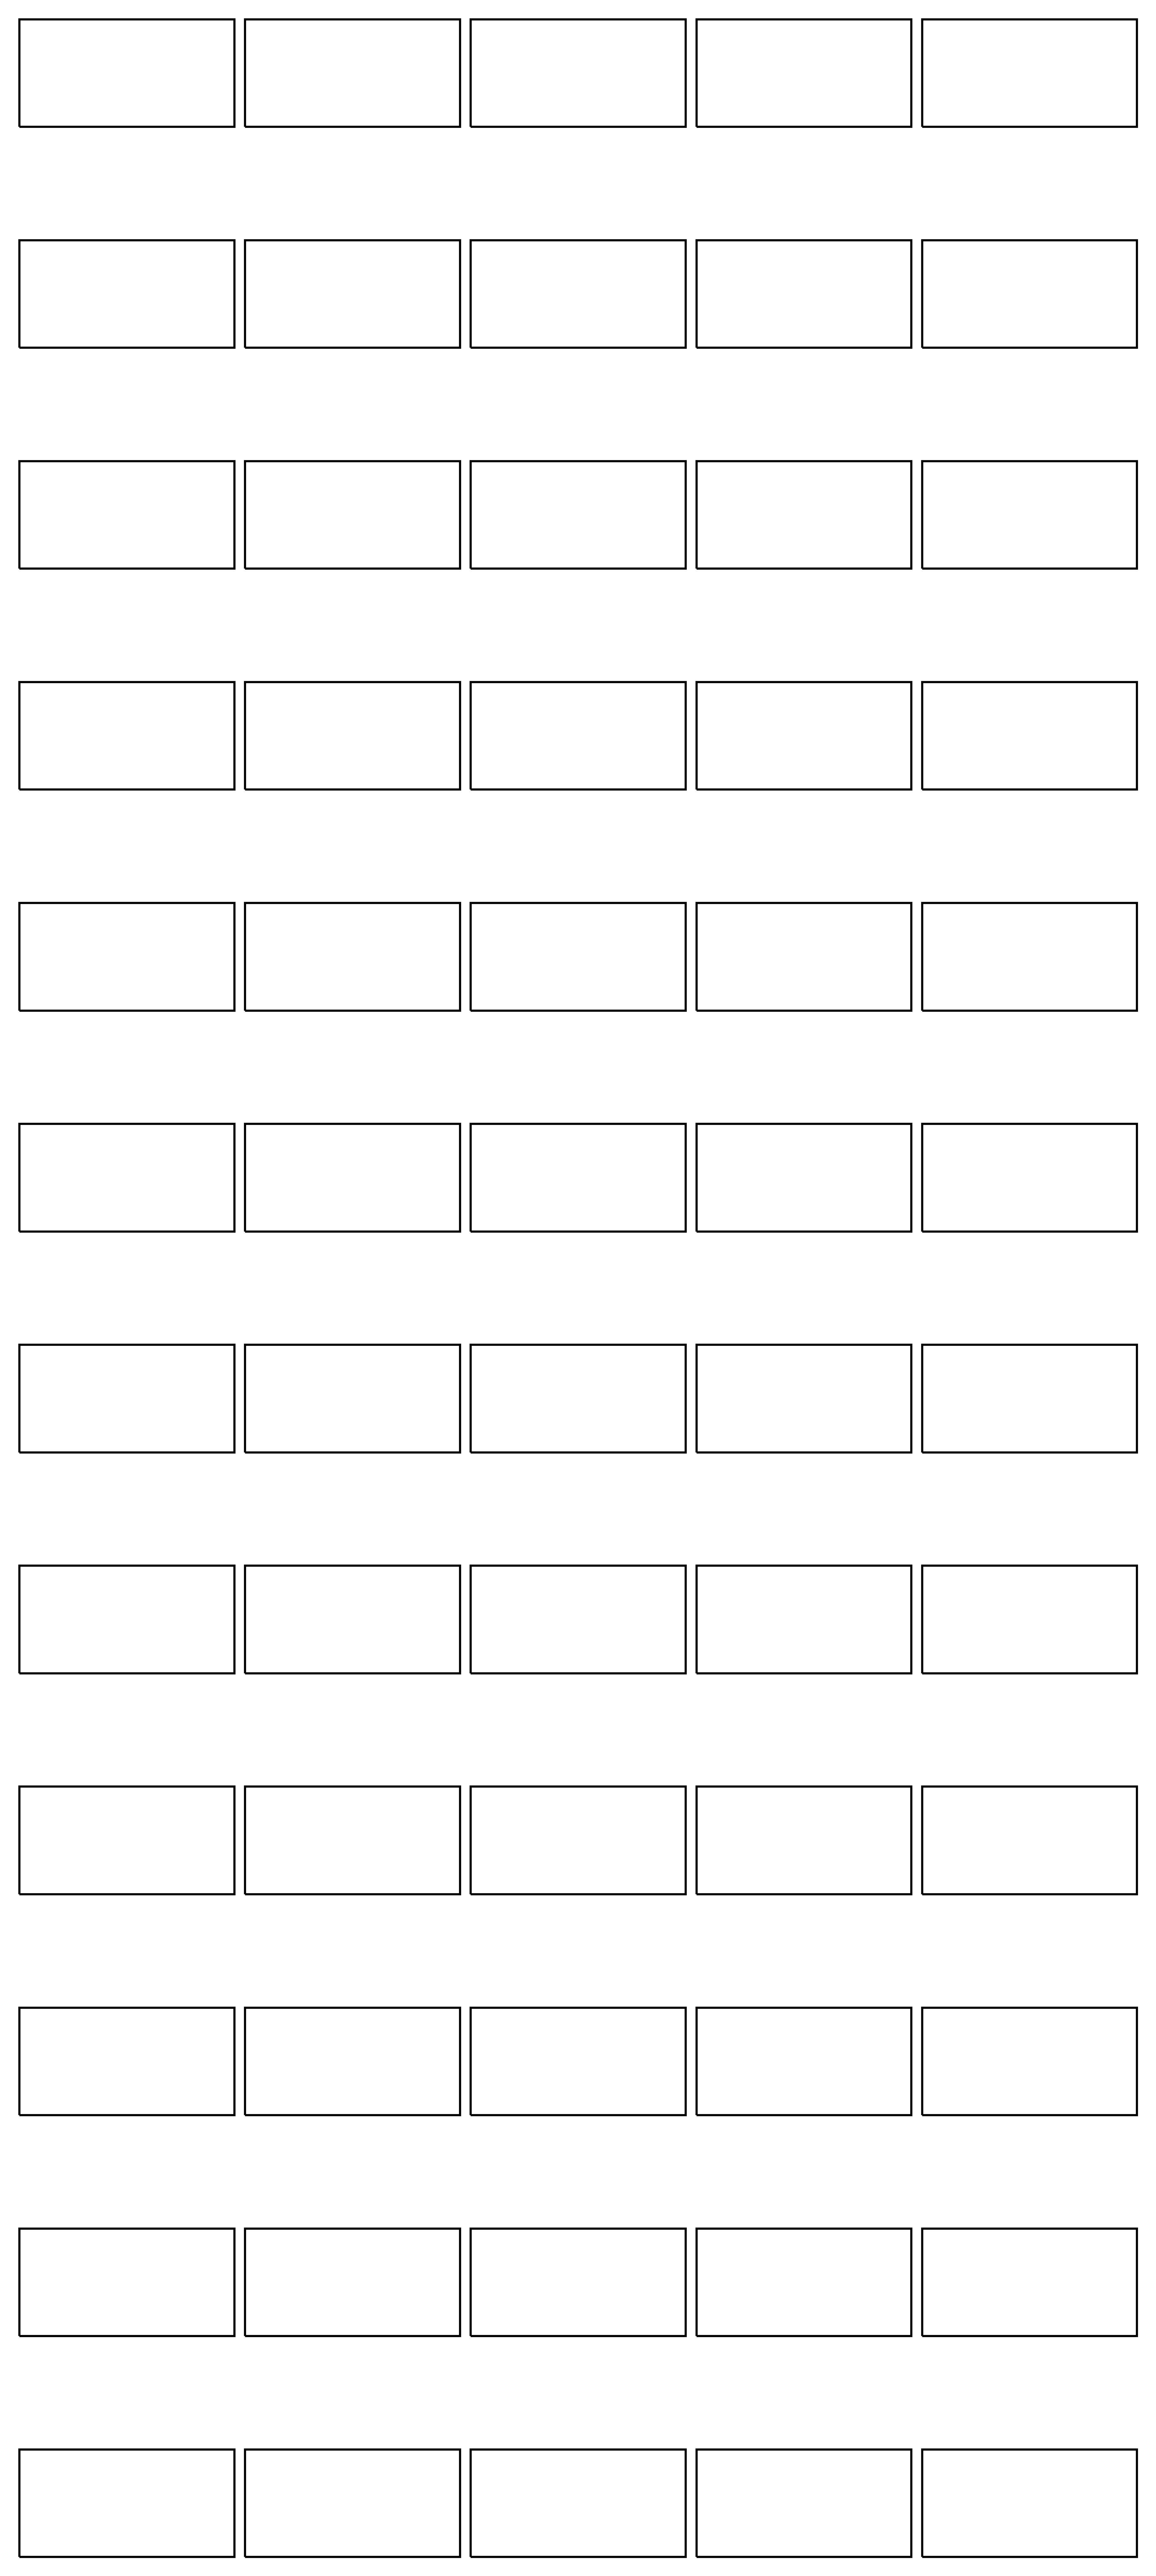

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "../src/fortran"))
from cletkf_wloc import common_da as cda


npz_file = (
    "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/"
    "3D_subsets_20240319_DAFCST_20240319180000/subset_20240320180000.npz"
)


data = np.load(npz_file)
ens  = data["state_ensemble"]          # (nx, ny, nz, Ne, 8)
lats = data["lats"]
lons = data["lons"]
nx, ny, nz, Ne, nvar = ens.shape
print(f"Loaded: nx={nx} ny={ny} nz={nz} Ne={Ne} nvar={nvar}")

# Compute reflectivity for all members
dbz = np.zeros((nx, ny, nz, Ne), dtype=np.float32)
for i in range(nx):
    for j in range(ny):
        for k in range(nz):
            for n in range(Ne):
                dbz[i,j,k,n] = cda.calc_ref(
                    ens[i,j,k,n,1],   # qr
                    ens[i,j,k,n,2],   # qs
                    ens[i,j,k,n,0],   # qg
                    ens[i,j,k,n,3],   # T
                    ens[i,j,k,n,4],   # P
                )

# Column-maximum reflectivity per member
dbz_max = np.nanmax(dbz, axis=2)  # (nx, ny, Ne)

# Plot all members in a grid
ncols = 5
nrows = int(np.ceil(Ne / ncols))
fig, axs = plt.subplots(
    nrows, ncols,
    figsize=(1.5 * ncols, 1.5 * nrows),
    sharex=True, sharey=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"hspace": 0.2, "wspace": 0.05},
    dpi=600
)
axs = axs.flatten()

for i in range(Ne):
    ax = axs[i]
    cm = ax.pcolormesh(lons, lats,
                       np.ma.masked_less(dbz_max[:,:,i].T, 5),
                       cmap="gist_ncar", vmin=0, vmax=70,
                       transform=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.5)
    ax.add_feature(_countries, linewidth=0.3)
    ax.add_feature(_states,    linewidth=0.3)
    ax.set_title(f"Mem {i+1:02d}", fontsize=7, fontweight="bold")
    if i % ncols == 0:
        ax.set_ylabel("Lat (°)", fontsize=6)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("Lon (°)", fontsize=6)

# Hide unused axes
for i in range(Ne, len(axs)):
    axs[i].set_visible(False)

cbar_ax = fig.add_axes([0.92, 0.05, 0.015, 0.9])
fig.colorbar(cm, cax=cbar_ax).set_label("Col-max Reflectivity [dBZ]", fontsize=11)
plt.suptitle("Ensemble Members – Column-Maximum Reflectivity", fontsize=13, fontweight="bold")
plt.subplots_adjust(right=0.91, left=0.05, top=0.95, bottom=0.05)
plt.show()


In [6]:
pos = data["pos_km"]
print(pos.shape)          # should be (nx, ny, nz, 3)
print(pos[0,0,:,2])       # z levels in km — should match your vertical grid
print(pos[-1,-1,0,:2]) 

(558, 898, 11, 3)
[ 0.25  0.5   1.    2.    3.    4.    5.    6.    8.   10.   12.  ]
[1124.7026 1785.2681]
